# Basics

### Gaussian distribution 

Let us start by recalling the **Gaussian distribution**. A variable $X$ is said to be normally distributed with mean $\mu$ and variance $\sigma^2$ if its probability density function (PDF) is 

$$
P_X(x) = \frac{1}{\sqrt{2 \pi \sigma^2}}\exp{\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)}
$$

In [176]:
#from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Let us plot a simple Gaussian distribution in 1-D with $m = 1000$ data points. We also have on the plot a kernel estimation. It looks normal because we have $m = 1000$ data points. However, even if we have less data, we can model the data as a function with a normal distribution if we assume a Gaussian prior. Then all we need is to estimate $\hat{\mu}$ and $\hat{\sigma}$, where

$$
\begin{aligned}
\hat{\mu} &= \frac{1}{m}\sum_{i = 1}^m x_i \\
\hat{\sigma}^2 &= \frac{1}{m}\sum_{i = 1}^m (x_i - \hat{\mu})^2 \\
\end{aligned}
$$

There is a question about what you divide by $m$ or $m-1$ or something else from me.

/tmp/ipykernel_3235477/1512819568.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(f_random[i], hist=True, rug=True)


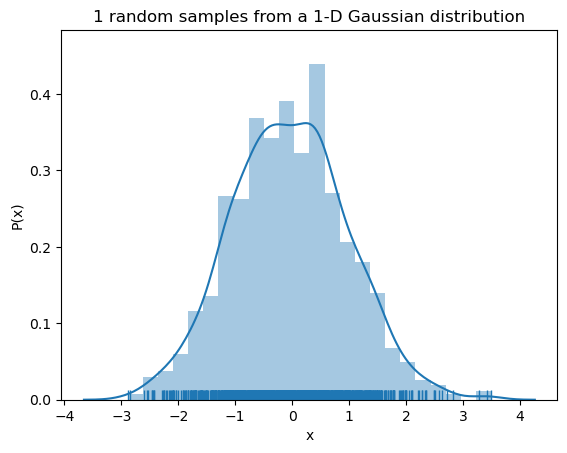

In [177]:
# Plot 1-D gaussian
n = 1         # n number of independent 1-D gaussian 
m= 1000       # m points in 1-D gaussian 
f_random = np.random.normal(size=(n, m)) 
# more information about 'size': https://www.sharpsightlabs.com/blog/numpy-random-normal/ 
#print(f_random.shape)

for i in range(n):
    #sns.distplot(f_random[i], hist=True, rug=True, vertical=True, color="orange")
    sns.distplot(f_random[i], hist=True, rug=True)

plt.title('1 random samples from a 1-D Gaussian distribution')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.show()

We can also project the 1-D normal onto a 2D space.

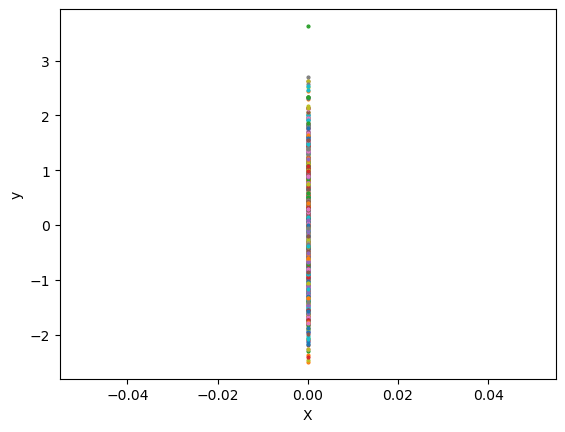

In [178]:
n = 1         # n number of independent 1-D gaussian 
m= 1000       # m points in 1-D gaussian  
f_random = np.random.normal(size=(n, m))

Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

plt.clf()
plt.plot(Xshow, f_random, 'o', linewidth=1, markersize=1, markeredgewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

Then project multiple normal distributions onto different locations in space.

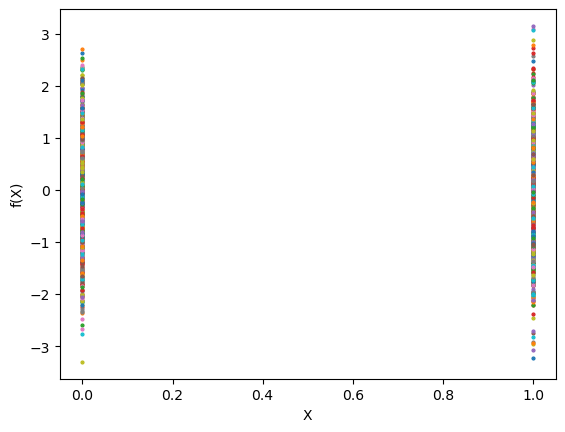

In [179]:
n = 2          
m = 1000
f_random = np.random.normal(size=(n, m))

Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

plt.clf()
plt.plot(Xshow, f_random, 'o', linewidth=1, markersize=1, markeredgewidth=2)
plt.xlabel('X')
plt.ylabel('f(X)')
plt.show()

Then connect lines.

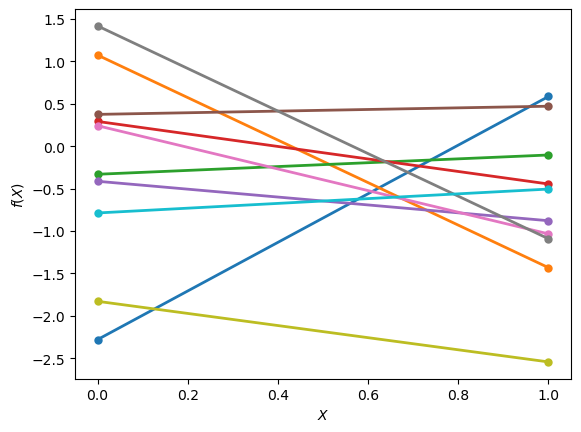

In [180]:
n = 2          
m = 10
f_random = np.random.normal(size=(n, m))

Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

plt.clf()
plt.plot(Xshow, f_random, '-o', linewidth=2, markersize=4, markeredgewidth=2)
plt.xlabel('$X$')
plt.ylabel('$f(X)$')
plt.show()

Now it looks like we have linear functions. We can use these functions to make predictions if new data points are on (or near) these lines. However, data does not always hold to linear functions. If we use more points across the domain [0, 1], we get nonlinear functions, but they are far too noisy to be useful (a claim that is made). *They certaintly do not seem explanatory*. It is claimed that we need smoother functions, which we will get by correlating the independent Gaussians we have formed up to this point.

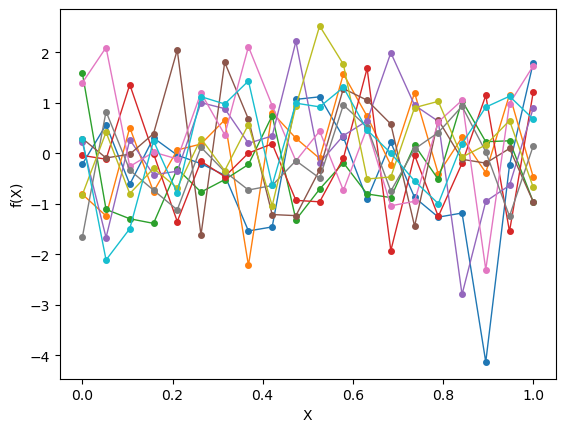

In [181]:
n = 20          
m = 10
f_random = np.random.normal(size=(n, m))

Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

plt.clf()
plt.plot(Xshow, f_random, '-o', linewidth=1, markersize=3, markeredgewidth=2)
plt.xlabel('X')
plt.ylabel('f(X)')
plt.show()

## Multivariate normal distribution (MVN)

Often some system is described by multiple variables that are correlated. In this situation, we can use an MVN model, where the PDF is described as

$$
N(x | \mu, \Sigma) = \frac{1}{(2\pi)^{D/2}|\Sigma|^{1/2}} \exp \left[ -\frac{1}{2}(x - \mu)^T\Sigma^{-1}(x - \mu) \right],
$$

where $D$ is the dimensionality of $x$, $\mu = E[x] \in R^D$, $\Sigma = \text{cov}[x] \in R^{D \times D}$.


Here is a 2-D MVN.

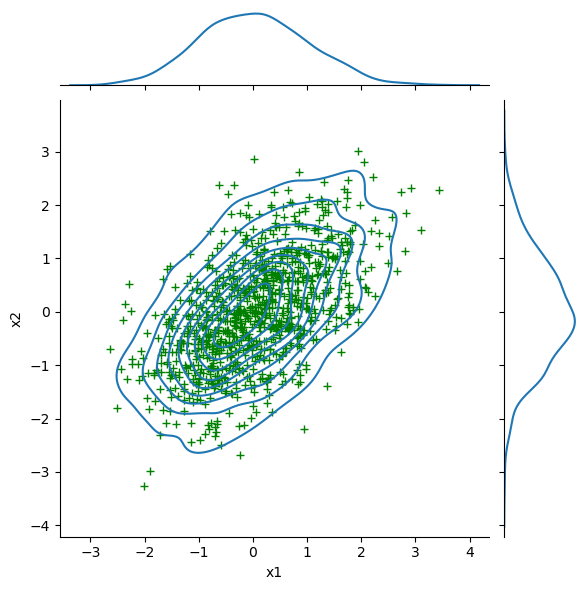

In [182]:
import pandas as pd
import seaborn as sns

mean, cov = [0., 0.], [(1., 0.6), (0.6, 1.)]
data = np.random.multivariate_normal(mean, cov, 1000)
df = pd.DataFrame(data, columns=["x1", "x2"])

g = sns.jointplot(data=df, x="x1", y="x2", kind="kde")

#(sns.jointplot("x1", "x2", data=df).plot_joint(sns.kdeplot))

g.plot_joint(plt.scatter, c="g", s=30, linewidth=1, marker="+")

#g.ax_joint.collections[0].set_alpha(0)
#g.set_axis_labels("<img src="/tex/8c76e0c69c5596634f9abb693bbf9438.svg?invert_in_darkmode&sanitize=true" align=middle width=17.614197149999992pt height=21.18721440000001pt/>", "<img src="/tex/1533fefb8348ed2119c7920bf5d7a8a5.svg?invert_in_darkmode&sanitize=true" align=middle width=17.614197149999992pt height=21.18721440000001pt/>");

#g.ax_joint.legend_.remove()
plt.show()

As a note, we are more interested in conditional probablity than joint probability for regression tasks. **(I think I get why...)**. By this I mean we are looking for $P(x_1 |x_2)$.

## Kernel

Back to drawing lines through things (and our incredibly messy functions), we want to smooth that incredibly ugly set of functions using a *kernel*. *In regression, we desire the predictions to be smooth and logical; similar inputs should yield similar outputs.* **(Notice that is what was wrong with our ugly functions! Similar starting inputs at $x = 0$ yielded completely different outputs!)**.

The tutorial introduces the kernel with the *dot product*, $A \cdot B = |A||B| \cos \theta$, a measure of similarity. It claims that there is a *feature space* and the kernel function helps lifts our data to the feature space and performs the dot product in the feature space in a computationally efficient manner, called the *kernel trick*. It claims, *formally, the kernel function $k(x, x')$ computes the similarity between functions in a high-dimensional feature space without explicitly transforming inputs.*

The squared exponential (SE) or Gaussian kernel is a popular kernel function to use **(I do not understand why)**, defined as

$$
\text{cov}(x_i, x_j) = \exp \left( -\frac{(x_i - x_j)^2}{2} \right).
$$

So now let us go back to our original ugly functions created by uncorrelated Gaussian distributions in space.

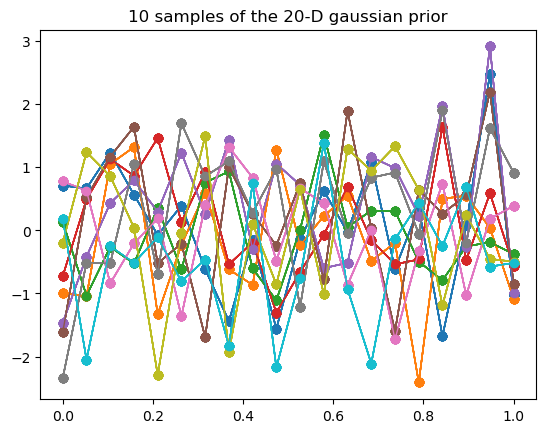

In [183]:
n = 20 
m = 10

mean = np.zeros(n)
cov = np.eye(n)

f_prior = np.random.multivariate_normal(mean, cov, m).T

plt.clf()

#plt.plot(Xshow, f_prior, '-o')
Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

for i in range(m):
    plt.plot(Xshow, f_prior, '-o', linewidth=1)
    
plt.title('10 samples of the 20-D gaussian prior')

plt.show()

Now here is the key. The kernel function actually makes it such that the normal distributions are correlated in space. It seems to just be a covariance function where points close in space to each other are highly corrrelated.

In [184]:
# Define the kernel
def kernel(a, b):
    sqdist = np.sum(a**2,axis=1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
    # np.sum( ,axis=1) means adding all elements columnly; .reshap(-1, 1) add one dimension to make (n,) become (n,1)
    return np.exp(-.5 * sqdist)

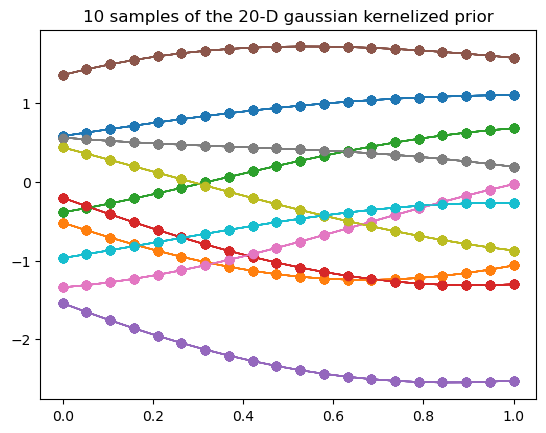

In [185]:
n = 20  
m = 10

Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

K_ = kernel(Xshow, Xshow)                  # k(x_star, x_star)        

mean = np.zeros(n)
cov = np.eye(n)

f_prior = np.random.multivariate_normal(mean, K_, m).T

plt.clf()

Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

for i in range(m):
    plt.plot(Xshow, f_prior, '-o', linewidth=1)
    
plt.title('10 samples of the 20-D gaussian kernelized prior')
plt.show()

<Figure size 640x480 with 0 Axes>

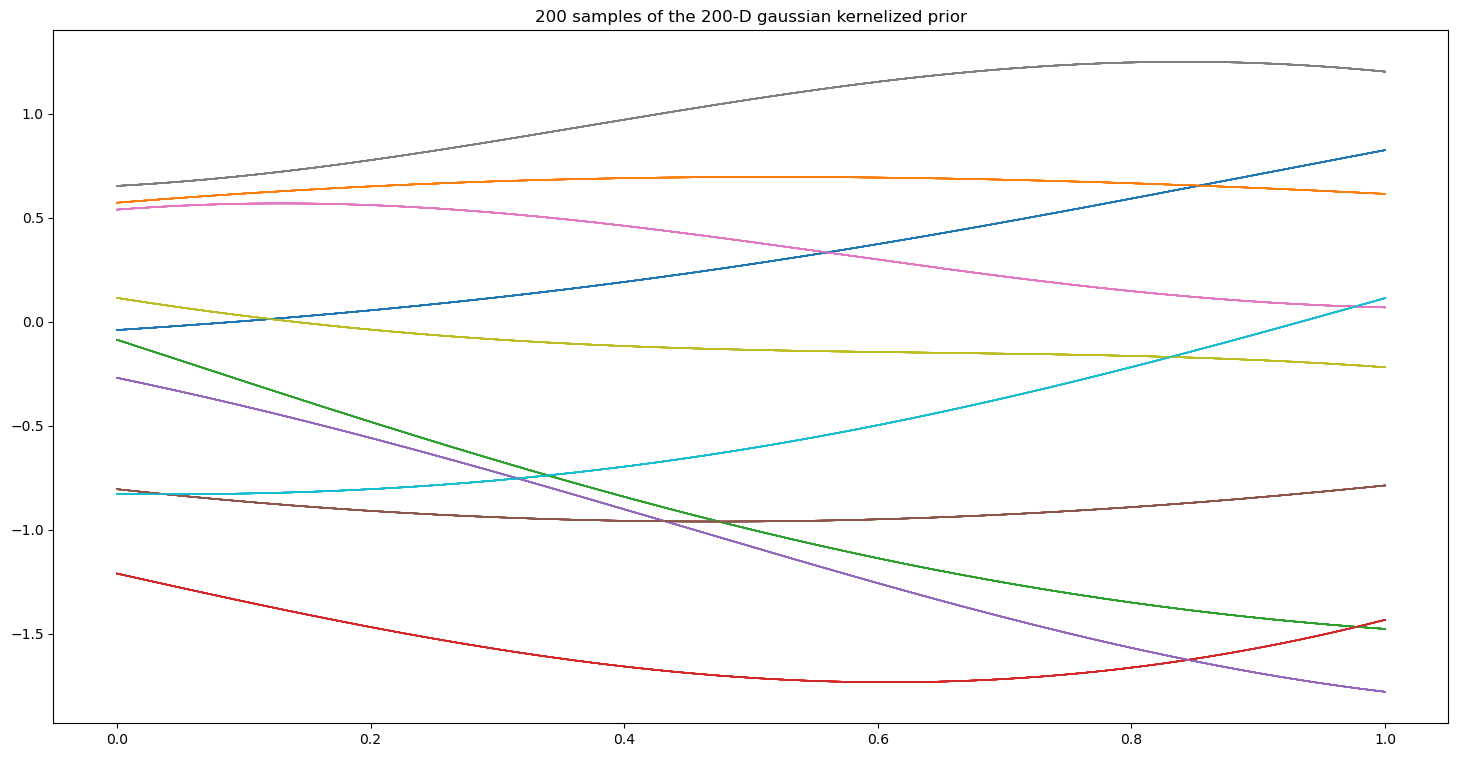

In [186]:
n = 500        
m = 10

Xshow = np.linspace(0, 1, n).reshape(-1,1)   

K_ = kernel(Xshow, Xshow)                    # k(x_star, x_star)        

mean = np.zeros(n)
cov = np.eye(n)

f_prior = np.random.multivariate_normal(mean, K_, m).T

plt.clf()
#plt.plot(Xshow, f_prior, '-o')
Xshow = np.linspace(0, 1, n).reshape(-1,1)   # n number test points in the range of (0, 1)

plt.figure(figsize=(18,9))
for i in range(m):
    plt.plot(Xshow, f_prior, '-', linewidth=1, markersize=2, markeredgewidth=1)
    
plt.title('200 samples of the 200-D gaussian kernelized prior')
#plt.axis([0, 1, -3, 3])
plt.show()

### Parametric vs. Non-parametric models

Parametric models assume a fixed number of parameters (i.e. a linear model with 2 parameters). When conducting regressions using parametric models, the complexity/flexibility is limited by the number of parameters (this is not inherently negative or positive). If the number of parameters grows with the number of data points, it is a non parametric model; they entail an infinite number of parameters.

# Gaussian Processes

## A brief review

Our goal for **regression** is to model a function $\mathbf{f}$ based on observed data $D$ from unknown function $\mathbf{f}$. Traditional nonlinear regression methods often give a single function that is considered to best fit the dataset. However, there could be more than one function that fits the dataset equally well. When the MVN was infinite, we could make predictions at any point using the infinite number of functions. These functions are MVN because it is our prior assumptions (?). More formally, the prior distribution of these infinite functions is MVN, representing the expected outcomes of $\mathbf{f}$ over inputs $x$ before observing data. When we have observations, we only keep functions that fit the data, forming the posterior distribution. The posterior is the prior updated with data. When we have new data, we use the current posterior as the prior.


## Definition of a Gaussian process

A Gaussian process model describes a probability distribution over possible functions that fit a set of points. Because we have a probability distribution over all possible functions, we can compute the means to represent a **maximum likelihood estimation** of the function, and the variances as an indicator of prediction confidence. Key points include: i) the function prior is updated with new observations, ii) a Gaussian rocess model is a probability distribution over possible functions, with any finite samples of functions being Gaussian distributed, iii) the mean function derived from the posterior distribution of possible functions *is the* function used for regression predictions.

The regression function modeled by Gaussian regression is

$$
p(\mathbf{f}|\mathbf{X}) \sim N(\mathbf{f}|\mu, \mathbf{K})
$$

where $\mathbf{X} = [x_1, ..., x_n]$ is the observed data points, $\mathbf{f} = [f(x_1), ... f(x_n)]$ is the observed function output, $\mu$ is the mean function and $\mathbf{K}_{ij} = k(x_i, x_j)$ is the kernel function. We usually default to $\mu = 0$ with no observation (especially if data is normalizaed to 0 mean). The Gaussian process is thus a distribution of functions whose shapes are determined by $\mathbf{K}$. If points $x_i, x_j$ are considered similar by $\mathbf{K}$, then $f(x_i), f(x_j)$ should be similar as well. The regression process using a Gaussian process is as follows: using observed data and a mean function $\mathbf{f}$ estimated from the observed data, we take new points $\mathbf{X}_*$ and predict $\mathbf{f}({\mathbf{X}_*})$. The joint distribution is 

$$
\begin{bmatrix}\mathbf{f} \\ \mathbf{f}_* \end{bmatrix} \sim N\left( \begin{bmatrix} m(\mathbf{X}) \\ m(\mathbf{X}_*) \end{bmatrix}, \begin{bmatrix} \mathbf{K} & \mathbf{K}_* \\ \mathbf{K}_*^T & \mathbf{K}_{**}\end{bmatrix} \right)\
$$

where $\mathbf{K} = k(\mathbf{X}, \mathbf{X})$, $\mathbf{K}_* = k(\mathbf{X}, \mathbf{X}_*)$, and $\mathbf{K}_{**} = k(\mathbf{X}_*, \mathbf{X}_*)$. We assume $\begin{bmatrix} m(\mathbf{X}) \\ m(\mathbf{X}_*) \end{bmatrix} = \mathbf{0}$. This equation describes the joint probability distribution $p(\mathbf{f}, \mathbf{f}_*|\mathbf{X}, \mathbf{X}_*)$, but we want the *conditional* distribution $p(\mathbf{f}_* | \mathbf{f}, \mathbf{X}, \mathbf{X}_*)$. We use conditional distribution of MVN (see A.2 of Rasmussen)to find that

$$
\mathbf{f}_* | \mathbf{f}, \mathbf{X}, \mathbf{X}_* \sim N \left( \mathbf{K}_*^T\mathbf{K}^{-1}\mathbf{f}, \mathbf{K}_{**} - \mathbf{K}_*^T\mathbf{K}^{-1}\mathbf{K}_* \right)
$$

*I am assuming we are using centered data and outputs or this does not make much sense methinks? ... duh we set the mean to be 0*.

It is realistic that we actually have noisy data $y = f(x) + \epsilon$, where we will state that $\epsilon \sim N(0, \sigma_n^2)$. The prior on these noisy observations is then $\text{cov}(y) = \mathbf{K} + \sigma^2_n \mathbf{I}$. Then the joint distribution is 

$$
\begin{bmatrix}\mathbf{y} \\ \mathbf{f}_* \end{bmatrix} \sim N\left( \begin{bmatrix} m(\mathbf{X}) \\ m(\mathbf{X}_*) \end{bmatrix}, \begin{bmatrix} \mathbf{K} + \sigma^2_n \mathbf{I} & \mathbf{K}_* \\ \mathbf{K}_*^T & \mathbf{K}_{**}\end{bmatrix} \right)\
$$

and the *conditional* distribution is

$$
\bar{\mathbf{f}}_* | \mathbf{f}, \mathbf{X}, \mathbf{X}_* \sim N \left( \mathbf{K}_*^T(\mathbf{K} + \sigma^2_n \mathbf{I})^{-1}\mathbf{f}, \mathbf{K}_{**} - \mathbf{K}_*^T(\mathbf{K} + \sigma^2_n \mathbf{I})^{-1}\mathbf{K}_* \right)
$$

*I've got a lot of questions\uncertainty...*

# Illustrative Example

We will be using Algorithm 2.1 from Rasmussen. I repeated the algorithm exactly (except for equation numbers).


$$
\boxed{
\begin{array}{ll}
\textbf{input:} &
X \text{ (inputs)},\;
y \text{ (targets)},\;
k \text{ (covariance function)},\;
\sigma_n^2 \text{ (noise level)},\;
\mathbf{x}_* \text{ (test input)}
\\[0.6em]
2: &
L := \operatorname{chol}\bigl(\mathbf{K} + \sigma_n^2 \mathbf{I}\bigr)
\\
& \alpha := L^{-\top}\bigl(L^{-1} \mathbf{y}\bigr)
\\[0.4em]
4: &
\bar{\mathbf{f}}_* := \mathbf{K}_*^{\top} \alpha
\qquad\Big\}\;\text{predictive mean}
\\
& v := L^{-1} \mathbf{K}_*
\\[0.4em]
6: &
\mathbb{V}[\mathbf{f}_*] := \mathbf{K}_{**} - v^{\top} v
\qquad\Big\}\;\text{predictive variance}
\\
& \log p(\mathbf{y} \mid \mathbf{X})
:= -\tfrac{1}{2} \mathbf{y}^{\top} \alpha
   - \sum_i \log L_{ii}
   - \tfrac{n}{2} \log 2\pi
\qquad
\\[0.6em]
8: &
\textbf{return: }\;
\bar{\mathbf{f}}_* \text{ (mean)},\;
\mathbb{V}[f_*] \text{ (variance)},\;
\log p(\mathbf{y} \mid \mathbf{X}) \text{ (log marginal likelihood)}
\end{array}
}
$$

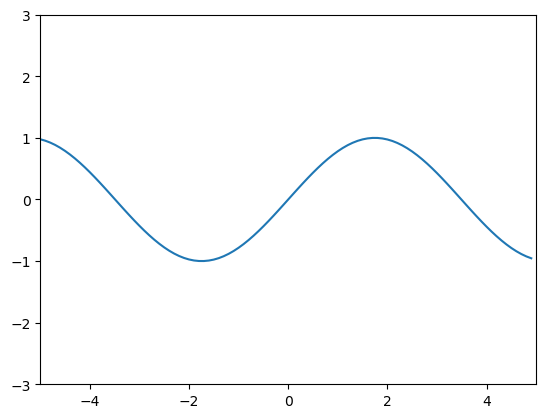

In [187]:
# This is the true unknown function we are trying to approximate
f = lambda x: np.sin(0.9*x).flatten()
#f = lambda x: (0.25*(x**2)).flatten()
x = np.arange(-5, 5, 0.1)

plt.plot(x, f(x))
plt.axis([-5, 5, -3, 3])
plt.show()

In [188]:
# Define the kernel
def kernel(a, b):
    kernelParameter_l = 0.1
    kernelParameter_sigma = 1.0
    sqdist = np.sum(a**2,axis=1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
    # np.sum( ,axis=1) means adding all elements columnly; .reshap(-1, 1) add one dimension to make (n,) become (n,1)
    return kernelParameter_sigma*np.exp(-.5 * (1/kernelParameter_l) * sqdist)

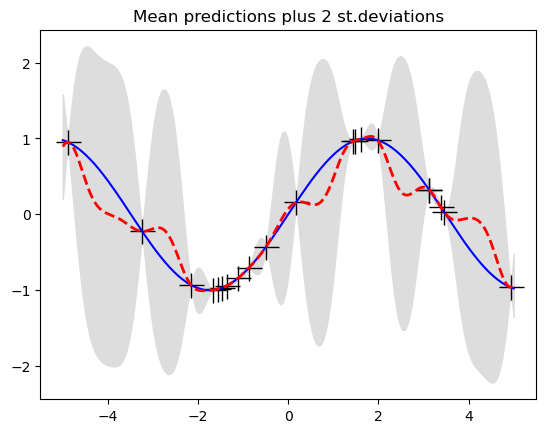

In [189]:
# Sample some input points and noisy versions of the function evaluated at
# these points. 
N = 20       # number of existing observation points (training points).
n = 200        # number of test points.
s = 0.00005    # noise variance.

X = np.random.uniform(-5, 5, size=(N,1))     # N training points 
y = f(X) + s*np.random.randn(N)

K = kernel(X, X)
L = np.linalg.cholesky(K + s*np.eye(N))     # line 1 

# points we're going to make predictions at.
Xtest = np.linspace(-5, 5, n).reshape(-1,1)

# compute the mean at our test points.
Lk = np.linalg.solve(L, kernel(X, Xtest))   # k_star = kernel(X, Xtest), calculating v := l\k_star
mu = np.dot(Lk.T, np.linalg.solve(L, y))    # \alpha = np.linalg.solve(L, y) 

# compute the variance at our test points.
K_ = kernel(Xtest, Xtest)                  # k(x_star, x_star)        
s2 = np.diag(K_) - np.sum(Lk**2, axis=0)   
s = np.sqrt(s2)

# PLOTS:
plt.figure(1)
plt.clf()
plt.plot(X, y, 'k+', ms=18)
plt.plot(Xtest, f(Xtest), 'b-')
plt.gca().fill_between(Xtest.flat, mu-2*s, mu+2*s, color="#dddddd")
plt.plot(Xtest, mu, 'r--', lw=2)
#plt.savefig('predictive.png', bbox_inches='tight', dpi=300)
plt.title('Mean predictions plus 2 st.deviations')
plt.show()
#plt.axis([-5, 5, -3, 3])

<Figure size 640x480 with 0 Axes>

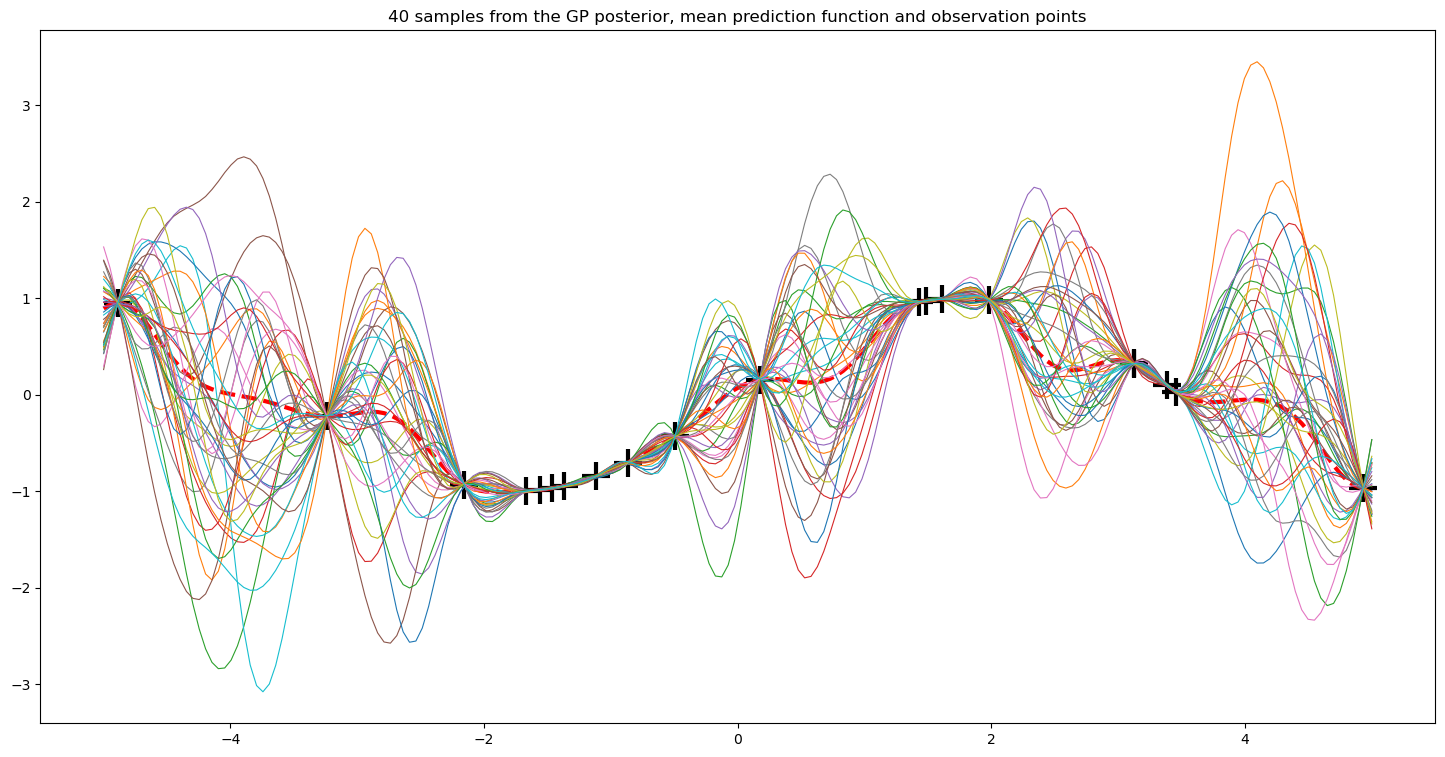

In [190]:
# draw samples from the posterior at our test points.
L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,40)))  # size=(n, m), m shown how many posterior  
plt.figure(3)
plt.clf()
plt.figure(figsize=(18,9))
plt.plot(X, y, 'k+', markersize=20, markeredgewidth=3)
plt.plot(Xtest, mu, 'r--', linewidth=3)
plt.plot(Xtest, f_post, linewidth=0.8)
plt.title('40 samples from the GP posterior, mean prediction function and observation points')
plt.show()
#plt.axis([-5, 5, -3, 3])
#plt.savefig('post.png', bbox_inches='tight', dpi=600)

## Parametric GPR

Let's try something new. Say we have a linear function with an attached zero-mean Gaussian process, where the function is 

$$
f(\mathbf{x}) = \mathbf{h}(\mathbf{x})^T\beta + u(\mathbf{x}), \; \; \text{where} \; \; \; \;  u(\mathbf{x}) \sim GP(0, k(\mathbf{x}, \mathbf{x}')),
$$

where $\mathbf{h}(\mathbf{x})$ are terms in a polynomial regression such that $\mathbf{h}(x) = (1, x, x^2, ...)$. There is noise associated with our measurement $\mathbf{y}_i$ of $f(\mathbf{x}_i)$, so that $\mathbf{y}_i$ can be modeled as

$$
\mathbf{y}_i = f(\mathbf{x}_i) + \epsilon_i,  \; \; \text{where} \; \; \; \; \epsilon_i \sim N(0, \sigma_n^2).
$$

There are two options to fit the model. One could optimize over the parameters $\beta$ with the other hyperparameters of the covariance function. We could instead take the prior on $\beta$ to be Gaussian, $\beta \sim N(b, B)$ and integrate out the parameters. We obtain another GP

$$
f(x) \sim GP(\mathbf{h}(\mathbf{x})^Tb, k(\mathbf{x}, \mathbf{x}') + \mathbf{h}(\mathbf{x})^TB\mathbf{h}(\mathbf{x}'))
$$

with added contribution in the covariance function casue with uncertainty in the parameters of the mean. We get predictions

$$
\begin{aligned}
\bar{f}(X_*) &= H_*^T \bar \beta + K_*^TK_y^{-1} (\mathbf{y} - H^T \bar \beta) = \bar{{u}} (X_*) + R^T \bar \beta, \\
\text{cov}(f_*) &= \text{cov}(u_*) + R^T(B^{-1} + HK_y^{-1}H^T)^{-1}R,
\end{aligned}
$$

where $R = H_* - HK_y^{-1}K_*$ and $\bar \beta = (B^{-1} + HK_y^{-1}H^T)^{-1}(HK_y^{-1}\mathbf{y} + B^{-1}b)$. As a note, $K_y = K + \sigma_n^2 I$. Consider a scenario where we have virtually no prior on $B$, i.e. $B^{-1} \to 0$. Then we get a predictive distribution indepedent of our prior on $b$, 

$$
\begin{aligned}
\bar{f}(X_*) &= \bar{{u}} (X_*) + R^T \bar \beta, \\
\text{cov}(f_*) &= \text{cov}(u_*) + R^T(HK_y^{-1}H^T)^{-1}R,
\end{aligned}
$$

where now  $\bar \beta = (HK_y^{-1}H^T)^{-1}(HK_y^{-1}\mathbf{y})$. 

**What I think is especially nice about this is that that the error in the output of the function is given, not necessarily in the parameter, and the output is what we care about**.



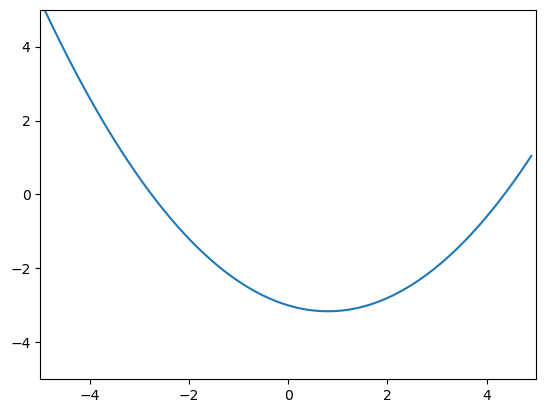

In [191]:
# This is the true unknown function we are trying to approximate
f = lambda x: x.flatten()
f = lambda x: (0.25*(x**2)  -.4*x - 3).flatten()
x = np.arange(-5, 5, 0.1)

plt.plot(x, f(x))
plt.axis([-5, 5, -5, 5])
plt.show()

[-3.00948664 -0.38846152  0.25085311]
(array([-2.99914305, -0.39868767,  0.25057918]), array([0.20008181]), np.int32(3), array([58.64789269, 14.33934159,  2.72705469]))


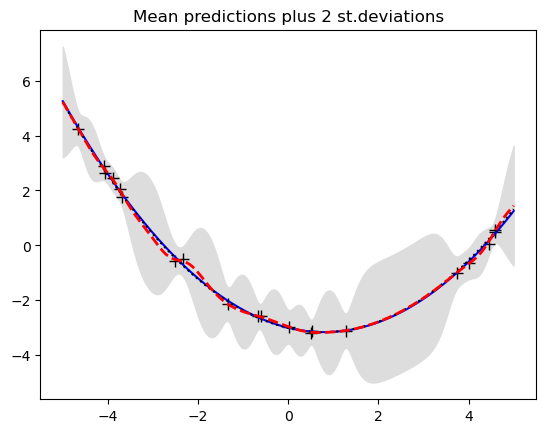

In [192]:
# Sample some input points and noisy versions of the function evaluated at
# these points. 
N = 20       # number of existing observation points (training points).
n = 200        # number of test points.
s = 0.1   # noise variance.

X = np.random.uniform(-5, 5, size=(N,1))     # N training points 
y = f(X) + s*np.random.randn(N)

K = kernel(X, X)
L = np.linalg.cholesky(K + s*np.eye(N))     # line 1 

# points we're going to make predictions at.
Xtest = np.linspace(-5, 5, n).reshape(-1,1)

# compute the mean at our test points.
Lk = np.linalg.solve(L, kernel(X, Xtest))   # k_star = kernel(X, Xtest), calculating v := l\k_star
mu = np.dot(Lk.T, np.linalg.solve(L, y))    # \alpha = np.linalg.solve(L, y) 

# compute the variance at our test points.
K_ = kernel(Xtest, Xtest)                  # k(x_star, x_star)   
K_new = K_ - Lk.T @ Lk     
s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
s = np.sqrt(s2)

## Parametric
H = X
H_star = Xtest

H      = np.column_stack([np.ones(N), X, X**2])
H_star = np.column_stack([np.ones(n), Xtest, Xtest**2])
def Kinv_dot(v):
    # Solve L w = v, then L.T u = w; u = K_y^{-1} v
    w = np.linalg.solve(L, v)
    u = np.linalg.solve(L.T, w)
    return u

# H: (N, p), y: (N,)
Ky_inv_H = Kinv_dot(H)           # (N, p)
Ky_inv_y = Kinv_dot(y)           # (N,)

A = H.T @ Ky_inv_H               # (p, p)
b = H.T @ Ky_inv_y               # (p,)

beta_hat = np.linalg.solve(A, b)
print(beta_hat)

R = H_star.T - H.T @ Kinv_dot(kernel(X, Xtest))
mu = mu + R.T @ beta_hat

c = np.linalg.solve(A, R)
K_new = K_new + (R.T @ c)
s2 = np.diag(K_new)
s = np.sqrt(s2)

print(np.linalg.lstsq(H, y))

# PLOTS:
plt.figure(1)
plt.clf()
plt.plot(X, y, 'k+', ms=8)
plt.plot(Xtest, f(Xtest), 'b-')
plt.plot(Xtest, H_star @ beta_hat, 'k:')
plt.gca().fill_between(Xtest.flat, mu-2*s, mu+2*s, color="#dddddd")
plt.plot(Xtest, mu, 'r--', lw=2)
#plt.savefig('predictive.png', bbox_inches='tight', dpi=300)
plt.title('Mean predictions plus 2 st.deviations')
plt.show()
#plt.axis([-5, 5, -3, 3])
